In [13]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from sktime.transformations.panel.rocket import MiniRocketMultivariate
import seaborn as sns

import matplotlib.pyplot as plt

# Intro

The objective here is to investigate possible user-clustering. In particular, from the results (all tasks) we see that there is large user variability and, for some users, the performance is really bad. I want to understand here if there is some correlation with the data, or not.

### USILaughs - congitive load

In [14]:
data = np.load("../data.nosync/usilaughs/data_right_cognitiveload_60s.npz")

In [15]:
X = data["values"]          # shape: (90, 240, 3)

# Choose the dimensionality reduction method: "tsne" or "pca"
reduction_method = "kpca"

# MiniRocket expects shape: (n_samples, n_channels, n_timepoints)
X_mr = np.transpose(X, (0, 2, 1))

# Fit MiniRocket and transform to feature space
minirocket = MiniRocketMultivariate(random_state=42)
minirocket.fit(X_mr)
X_features = minirocket.transform(X_mr)

gamma = 1.0 / X_features.shape[1]
sq_dists = pairwise_distances(X_features, metric="sqeuclidean")
rbf_sim = np.exp(-gamma * sq_dists)
D = rbf_sim
# D = 1.0 - rbf_sim
# np.fill_diagonal(D, 0.0)
    
if reduction_method.lower() == "tsne":
    # Build precomputed pairwise distance matrix in MiniRocket feature space
    # Build an RBF similarity matrix, then convert it to a distance-like matrix for t-SNE
    

    X_2d = TSNE(
        n_components=2,
        metric="precomputed",
        perplexity=10,
        init="random",
        learning_rate="auto",
        random_state=42,
    ).fit_transform(D)
    projection_name = "t-SNE"
elif reduction_method.lower() == "pca":
    X_2d = PCA(n_components=2, random_state=32).fit_transform(X_features)
    projection_name = "PCA"
elif reduction_method.lower() == "kpca":
    X_2d = KernelPCA(n_components=2, kernel="rbf", gamma=gamma, random_state=32).fit_transform(X_features)
    projection_name = "Kernel PCA"
else:
    raise ValueError(f"Unsupported reduction_method: {reduction_method}")

x_axis_label = f"{projection_name} 1"
y_axis_label = f"{projection_name} 2"

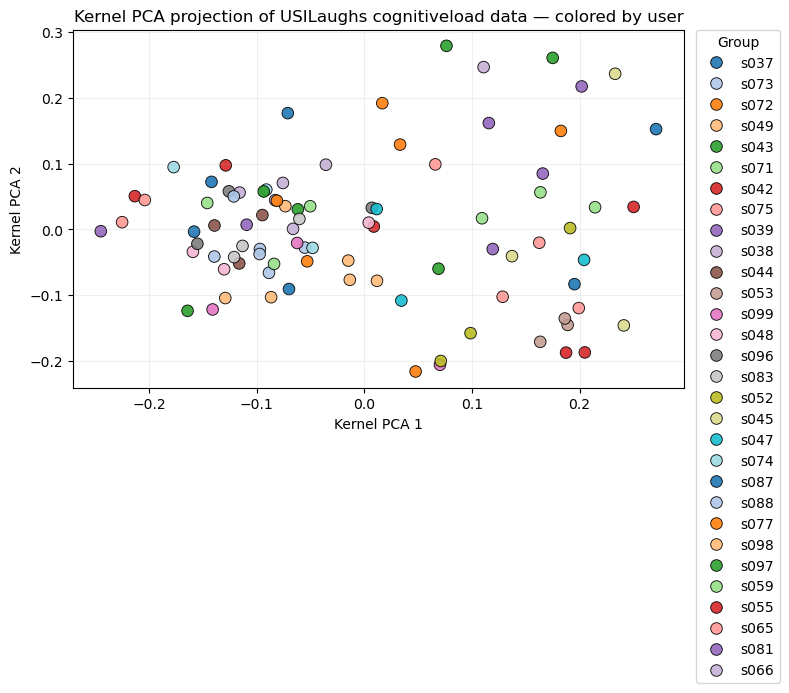

Original shape: (90, 240, 3)
Reduced shape: (90, 2)


In [17]:
# Plot with seaborn (categorical hue for subject/group IDs)
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=data['groups'],
    palette="tab20",
    s=70,
    alpha=0.9,
    edgecolor="k",
)

plt.title(f"{projection_name} projection of USILaughs cognitiveload data — colored by user")
plt.xlabel(x_axis_label)
plt.ylabel(y_axis_label)
plt.grid(alpha=0.2)

# Move legend outside to keep plot readable
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

print("Original shape:", X.shape)
print("Reduced shape:", X_2d.shape)

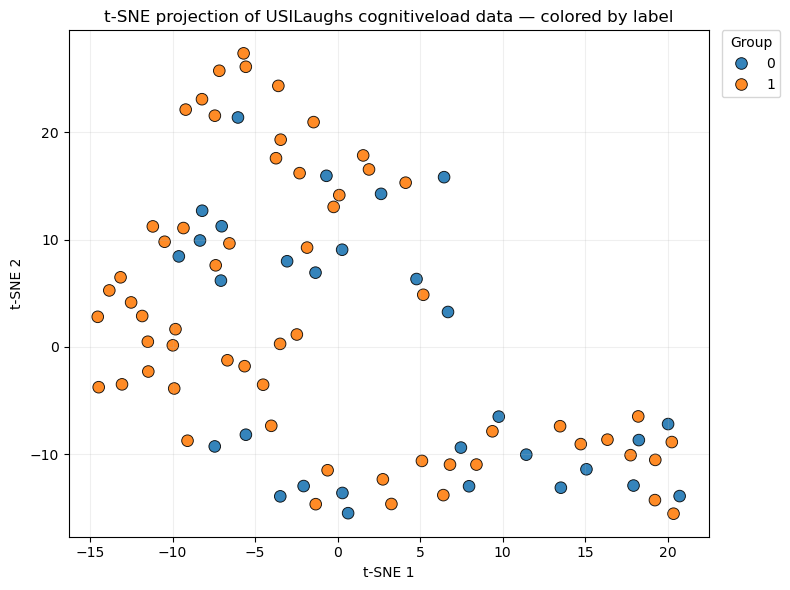

Original shape: (90, 240, 3)
Reduced shape: (90, 2)


: 

In [ ]:
# Plot with seaborn (categorical hue for subject/group IDs)
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=data['labels'],
    s=70,
    alpha=0.9,
    edgecolor="k",
)

plt.title(f"{projection_name} projection of USILaughs cognitiveload data — colored by label")
plt.xlabel(x_axis_label)
plt.ylabel(y_axis_label)
plt.grid(alpha=0.2)

# Move legend outside to keep plot readable
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

print("Original shape:", X.shape)
print("Reduced shape:", X_2d.shape)

In [18]:
results = pd.read_csv(
    "../outputs/usilaughs-right/multirun_2026-01-12-16-28-21/0/reports.csv", index_col=0
)
print(
    "Balanced accuracy for UME + logistic regression: %i ± %i %%"
    % (
        results["balanced_accuracy_score"].mean() * 100,
        results["balanced_accuracy_score"].sem() * 1.98 * 100,
    )
)

results['user'] = np.unique(data['groups'])

Balanced accuracy for UME + logistic regression: 70 ± 10 %


In [19]:
acc_user = np.array([results[results['user'] == val]['balanced_accuracy_score'].iloc[0] for val in data['groups']])

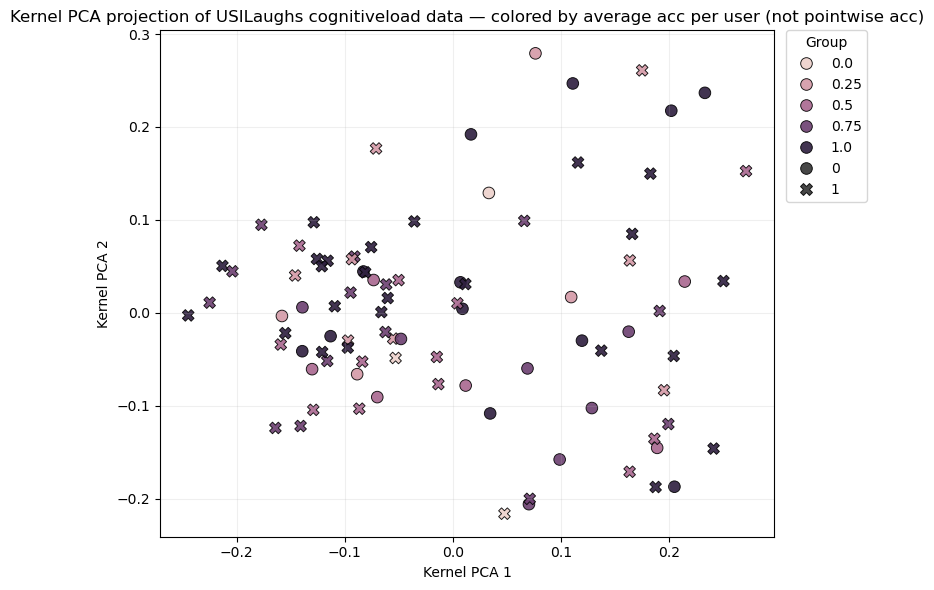

Original shape: (90, 240, 3)
Reduced shape: (90, 2)


In [20]:
# Plot with seaborn (categorical hue for subject/group IDs)
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=acc_user,
    style=data['labels'].astype(str),  # Different marker for each label
    # palette="tab10",
    s=70,
    alpha=0.9,
    edgecolor="k",
)

plt.title(f"{projection_name} projection of USILaughs cognitiveload data — colored by average acc per user (not pointwise acc)")
plt.xlabel(x_axis_label)
plt.ylabel(y_axis_label)
plt.grid(alpha=0.2)

# Move legend outside to keep plot readable
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

print("Original shape:", X.shape)
print("Reduced shape:", X_2d.shape)